##Part 1 — Data Engineering, SQL Querying & Exploratory Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset


In [5]:
df = pd.read_csv("/content/googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
# Basic shape and structure
print("Shape:",df.shape)


print("\n------INFO-------")
df.info()

print("\n------DESCRIBE-------")
df.describe()

print("\n-------DESCRIBE NON-NUMERIC-------")
df.describe(include="all")


Shape: (10841, 13)

------INFO-------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

------DESCRIBE-------

-------DESCRIBE NON-NUMERIC-------


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# flag the columns with missing values
missing = df.isnull().sum()
missing_cols = missing[missing>0]
print(missing_cols)

Rating            1474
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64


In [8]:
# check data type
print(df.dtypes)

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


In [9]:
print("------ Checking for possible dtype mismatches ------")

for col in df.select_dtypes(include="object").columns:
    sample = df[col].dropna().astype(str).head(20)

    # Remove common symbols
    stripped = sample.str.replace(r"[$,%+ ]", "", regex=True)

    # Check how many values look numeric
    numeric_like = stripped.str.match(r"^-?\d+(\.\d+)?$").mean()

    if numeric_like > 0.7:
        print(f"Column '{col}' is stored as object but appears numeric.")
        print("Sample values:", sample.tolist()[:5])

------ Checking for possible dtype mismatches ------
Column 'Reviews' is stored as object but appears numeric.
Sample values: ['159', '967', '87510', '215644', '967']
Column 'Installs' is stored as object but appears numeric.
Sample values: ['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+']
Column 'Price' is stored as object but appears numeric.
Sample values: ['0', '0', '0', '0', '0']


In [10]:
# missing values and percentage
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

print(pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}))

                Missing Values  Percentage
App                          0    0.000000
Category                     0    0.000000
Rating                    1474   13.596532
Reviews                      0    0.000000
Size                         0    0.000000
Installs                     0    0.000000
Type                         1    0.009224
Price                        0    0.000000
Content Rating               1    0.009224
Genres                       0    0.000000
Last Updated                 0    0.000000
Current Ver                  8    0.073794
Android Ver                  3    0.027673


###Step 2 - Clean the Dataset

In [12]:
# --- A. Handle missing values (column by column, justified) ---

# Columns with missing values
missing_cols = df.columns[df.isnull().any()]

threshold = 0.10  # 10% missing rule

for col in missing_cols:
    pct_missing = df[col].isnull().mean()

    if pct_missing > threshold:
        print(f"Dropping column '{col}' — {pct_missing:.1%} missing")
        df.drop(columns=[col], inplace=True)

    else:
        if df[col].dtype in ["float64", "int64"]:
            fill_val = df[col].median()
            df[col] = df[col].fillna(fill_val)
            print(f"Imputed '{col}' with median ({fill_val})")

        else:
            fill_val = df[col].mode()[0]
            df[col] = df[col].fillna(fill_val)
            print(f"Imputed '{col}' with mode ({fill_val})")

Dropping column 'Rating' — 13.6% missing
Imputed 'Type' with mode (Free)
Imputed 'Content Rating' with mode (Everyone)
Imputed 'Current Ver' with mode (Varies with device)
Imputed 'Android Ver' with mode (4.1 and up)


In [13]:
import numpy as np
import pandas as pd

# Convert Reviews to numeric
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Clean Installs
if df["Installs"].dtype == "object":
    df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
    df["Installs"] = df["Installs"].str.replace("+", "", regex=False)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Detect outliers using IQR
for col in ["Reviews", "Installs"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"{col}: {len(outliers)} outliers")
    print(f"Lower Bound = {lower_limit:.2f}")
    print(f"Upper Bound = {upper_limit:.2f}\n")

Reviews: 1924 outliers
Lower Bound = -82068.25
Upper Bound = 136881.75

Installs: 828 outliers
Lower Bound = -7497500.00
Upper Bound = 12498500.00



In [14]:
# Convert the column to numeric
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")


# Ensure 'Installs' is numeric, handling potential non-numeric values from previous steps if any
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")



In [15]:
# Remove duplicate rows
before = len(df)

df.drop_duplicates(inplace=True)

after = len(df)

print(f"Removed {before - after} duplicate rows")

Removed 483 duplicate rows


In [16]:
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].median())
df["Installs"] = df["Installs"].fillna(df["Installs"].median())

###Step 3 SQL Query

In [20]:
import sqlite3
# --- Load cleaned dataframe into SQLite ---
conn = sqlite3.connect("googleplaystore.db")
df.to_sql("main_table", conn, if_exists="replace", index=False)
cursor = conn.cursor()

In [21]:
query = "SELECT * FROM main_table LIMIT 2;"
result = pd.read_sql(query, conn)

print(result)

                                              App        Category  Reviews  \
0  Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN    159.0   
1                             Coloring book moana  ART_AND_DESIGN    967.0   

  Size  Installs  Type Price Content Rating                     Genres  \
0  19M   10000.0  Free     0       Everyone               Art & Design   
1  14M  500000.0  Free     0       Everyone  Art & Design;Pretend Play   

       Last Updated Current Ver   Android Ver  
0   January 7, 2018       1.0.0  4.0.3 and up  
1  January 15, 2018       2.0.0  4.0.3 and up  


In [23]:
# Query 1: WHERE with comparison operator
# --- Query 1: WHERE filter using a comparison operator ---
q1 = """
SELECT App, Category,  Installs
FROM main_table
WHERE Installs >= 1000000;
"""
df_q1 = pd.read_sql_query(q1, conn)
print("Query 1: Apps with Installs >=  1000000")
display(df_q1.head())

Query 1: Apps with Installs >=  1000000


,App,Category,Installs
0,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,5000000.0
1,Sketch - Draw & Paint,ART_AND_DESIGN,50000000.0
2,Infinite Painter,ART_AND_DESIGN,1000000.0
3,Garden Coloring Book,ART_AND_DESIGN,1000000.0
4,Text on Photo - Fonteee,ART_AND_DESIGN,1000000.0


In [24]:
# --- Query 2: WHERE filter using IN and BETWEEN ---

q2 = """
SELECT App, Category, Reviews
FROM main_table
WHERE Category IN ('GAME', 'FAMILY', 'TOOLS')
AND Reviews BETWEEN 1000 AND 50000;
"""

df_q2 = pd.read_sql_query(q2, conn)

print("Query 2: Apps in selected categories with Reviews between 1000 and 50000")
display(df_q2.head())

Query 2: Apps in selected categories with Reviews between 1000 and 50000


,App,Category,Reviews
0,Zombie Hunter King,GAME,10306.0
1,Block Puzzle Classic Legend !,GAME,17039.0
2,Super Jim Jump - pixel 3d,GAME,10393.0
3,Bubble Shooter 2,GAME,23005.0
4,Marble - Temple Quest,GAME,42053.0


In [25]:
# ----Query 3: Aggregate function + group by ---
q3 = """
SELECT Category,
COUNT(*) AS num_apps,
AVG(Reviews) AS avg_reviews,
SUM(Installs) AS max_installs
FROM main_table
GROUP BY Category;
"""

df_q3 = pd.read_sql_query(q3, conn)

print("Query 3: Number of apps, average reviews, and maximum installs by categor")
display(df_q3.head())

Query 3: Number of apps, average reviews, and maximum installs by categor


,Category,num_apps,avg_reviews,max_installs
0,1.9,1,1680.000000,1.000000e+05
1,ART_AND_DESIGN,65,26376.000000,1.243381e+08
2,AUTO_AND_VEHICLES,85,13690.188235,5.313021e+07
3,BEAUTY,53,7476.226415,2.719705e+07
4,BOOKS_AND_REFERENCE,230,95100.986957,1.916470e+09


In [26]:
# --- Query 4: HAVING clause filtering on aggregated value ---

q4 = """
SELECT Category,
       COUNT(*) AS num_apps,
       AVG(Reviews) AS avg_reviews
FROM main_table
GROUP BY Category
HAVING COUNT(*) > 50
AND AVG(Reviews) > 10000;
"""

df_q4 = pd.read_sql_query(q4, conn)

print("Query 4: Categories with more than 50 apps and average reviews greater than 10000")
display(df_q4.head())

Query 4: Categories with more than 50 apps and average reviews greater than 10000


,Category,num_apps,avg_reviews
0,ART_AND_DESIGN,65,26376.000000
1,AUTO_AND_VEHICLES,85,13690.188235
2,BOOKS_AND_REFERENCE,230,95100.986957
3,BUSINESS,427,28941.852459
4,COMICS,60,56387.933333


In [27]:
# --- Query 5: ORDER BY + LIMIT ---
q5 = """
SELECT App, Category, Reviews, Installs
FROM main_table
ORDER BY Reviews DESC
LIMIT 10;
"""
df_q5 = pd.read_sql_query(q5, conn)
print("\nQuery 5: Top 10 apps by number of reviews")
display(df_q5.head(10))



Query 5: Top 10 apps by number of reviews


,App,Category,Reviews,Installs
0,Facebook,SOCIAL,78158306.0,1.000000e+09
1,Facebook,SOCIAL,78128208.0,1.000000e+09
2,WhatsApp Messenger,COMMUNICATION,69119316.0,1.000000e+09
3,WhatsApp Messenger,COMMUNICATION,69109672.0,1.000000e+09
4,Instagram,SOCIAL,66577446.0,1.000000e+09
5,Instagram,SOCIAL,66577313.0,1.000000e+09
6,Instagram,SOCIAL,66509917.0,1.000000e+09
7,Messenger – Text and Video Chat for Free,COMMUNICATION,56646578.0,1.000000e+09
8,Messenger – Text and Video Chat for Free,COMMUNICATION,56642847.0,1.000000e+09
9,Clash of Clans,GAME,44893888.0,1.000000e+08


In [29]:
# --- Query 6: Multiple WHERE conditions using AND / OR ---

q6 = """
SELECT App, Category, Type, Price, Reviews
FROM main_table
WHERE (Type = 'Free' OR Price = '0')
  AND Reviews >= 10000
  AND Category = 'GAME';
"""

df_q6 = pd.read_sql_query(q6, conn)

print("Query 6: Free games with Reviews >= 10000")
display(df_q6.head())

Query 6: Free games with Reviews >= 10000


,App,Category,Type,Price,Reviews
0,ROBLOX,GAME,Free,0,4447388.0
1,Subway Surfers,GAME,Free,0,27722264.0
2,Candy Crush Saga,GAME,Free,0,22426677.0
3,Solitaire,GAME,Free,0,254258.0
4,Bubble Shooter,GAME,Free,0,148897.0


In [30]:
# --- Save all query results to CSV files ---

df_q1.to_csv("query1_installs_filter.csv", index=False)
df_q2.to_csv("query2_category_in_reviews_between.csv", index=False)
df_q3.to_csv("query3_groupby_category.csv", index=False)
df_q4.to_csv("query4_having_category.csv", index=False)
df_q5.to_csv("query5_top10_reviews.csv", index=False)
df_q6.to_csv("query6_free_games_filter.csv", index=False)

# Close the database connection
conn.close()

print("All SQL queries executed successfully and results saved as CSV files.")

All SQL queries executed successfully and results saved as CSV files.


step4 vizulization

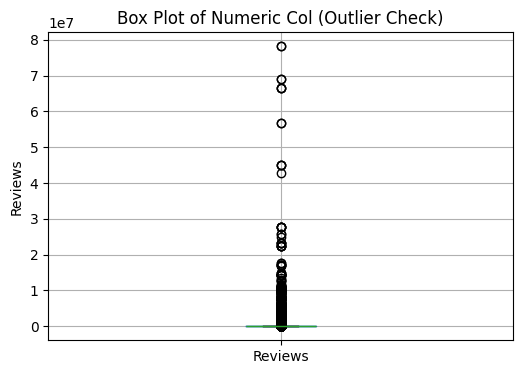

In [31]:
import matplotlib.pyplot as plt

# 1. Box plot — outlier check
plt.figure(figsize=(6, 4))
df.boxplot(column="Reviews")
plt.title("Box Plot of Numeric Col (Outlier Check)")
plt.ylabel("Reviews")
plt.show()

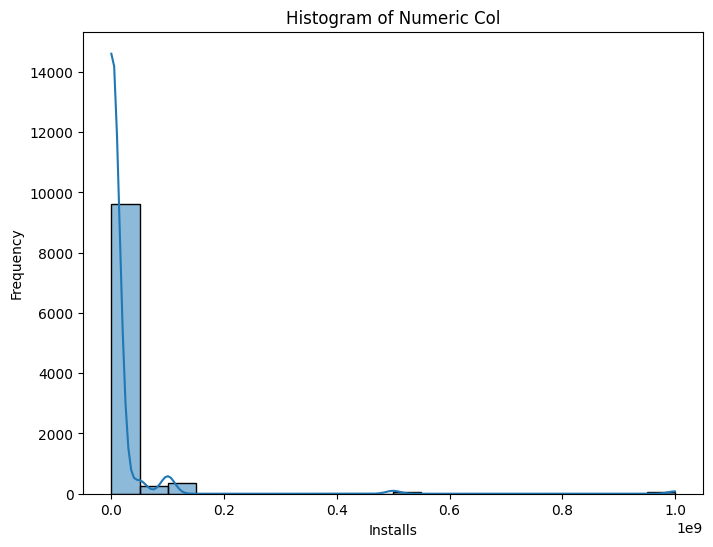

In [32]:
# 2 one histogram chart
plt.figure(figsize=(8, 6))
sns.histplot(df["Installs"], bins=20, kde=True)
plt.title("Histogram of Numeric Col")
plt.xlabel("Installs")
plt.ylabel("Frequency")
plt.show()

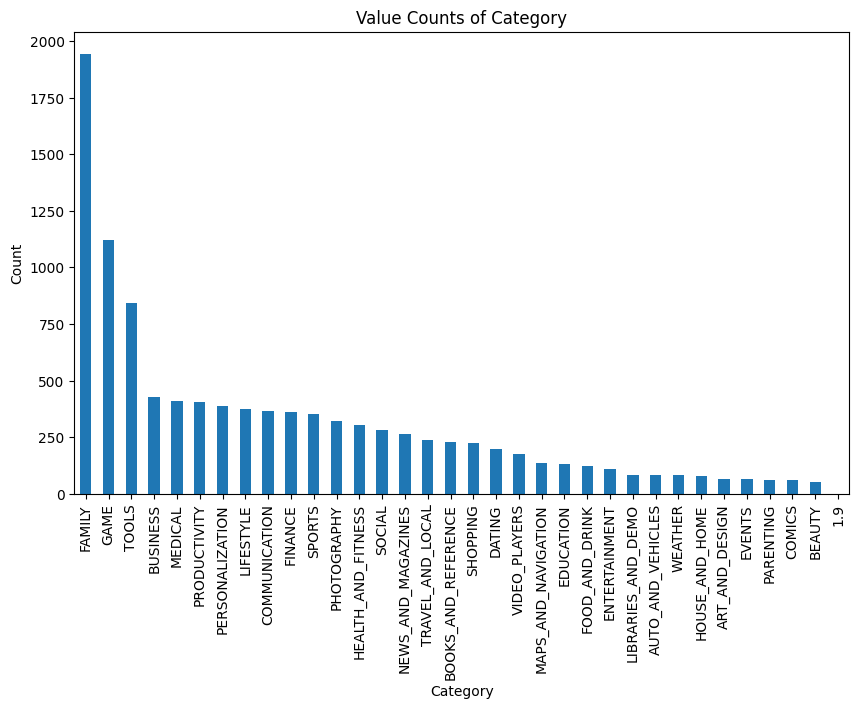

In [33]:
# 3 bar chart built from a value_count()
plt.figure(figsize=(10, 6))
df["Category"].value_counts().plot(kind="bar")
plt.title("Value Counts of Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

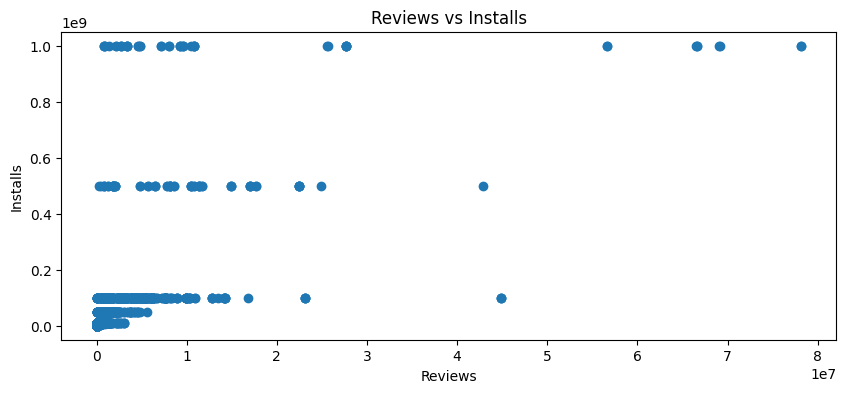

In [34]:
plt.figure(figsize=(10,4))
plt.scatter(df['Reviews'], df['Installs'])
plt.title("Reviews vs Installs")
plt.xlabel("Reviews")
plt.ylabel("Installs")
plt.show()


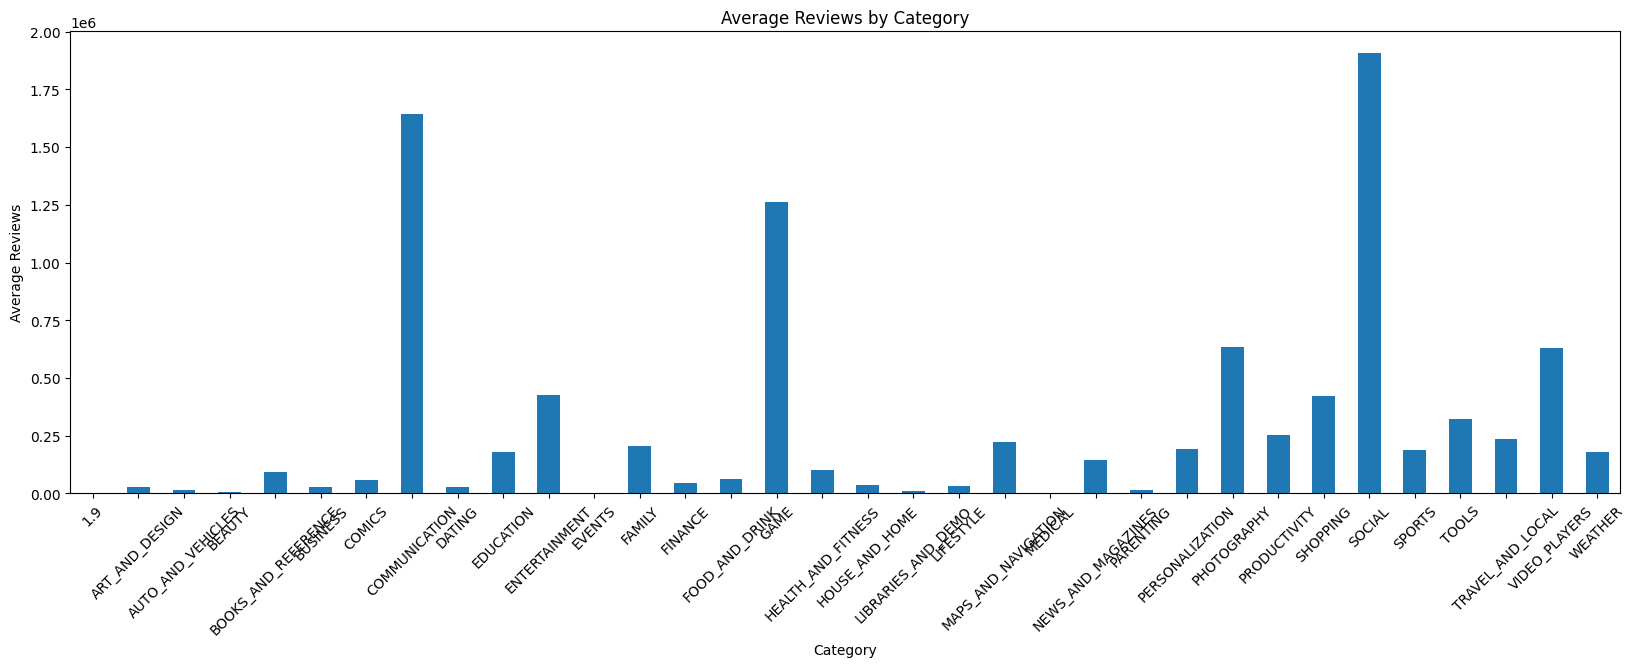

In [35]:
# plot a group by function average reviews by category
grouped = df.groupby("Category")["Reviews"].mean()

plt.figure(figsize=(20,6))
grouped.plot(kind="bar")

plt.title("Average Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Average Reviews")

plt.xticks(rotation=45)
plt.show()

**Insights**

1) Rating had the most missing data by far — 1,474 of 10,841 apps (13.6%) had no rating, more than 1,000x any other column's missing rate, which is why it was the one column dropped rather than imputed (the 10% threshold rule).

2) Duplicates made up ~4.5% of the raw data — 483 of 10,841 rows were exact duplicates, meaning nearly 1 in 22 listings was a repeat entry before cleaning.

3) Reviews is heavily right-skewed — IQR bounds of roughly ‑82,068 to 136,882 reviews flagged 1,924 apps (about 18% of the dataset) as outliers, all on the high end, driven by a handful of mega-apps.

4) Installs are even more concentrated at the top — 828 apps (about 7.6%) fell outside the IQR bounds (‑7.5M to 12.5M installs), and "1,000,000+" was the single most common install bucket, appearing 1,579 times.

5) A small set of communication/social apps dominate engagement — Facebook, WhatsApp, Instagram, and Messenger each logged 56–78 million reviews and all sit at the 1 billion+ installs tier, while the 10th-ranked app (Clash of Clans) has installs an order of magnitude lower (100M) despite still posting ~45M reviews.